In [9]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random
import os

In [10]:
# Step 1: Define State
class State(BaseModel):
    messages: Annotated[list, add_messages]
    

In [23]:
# Step 2: Create graph
graph_builder = StateGraph(State)

In [24]:
# Step 3: Create node
llm = ChatOpenAI(model = "google/gemma-4-e4b",
                base_url = "http://localhost:1234/v1",
                api_key = "lmstudio")

def chatbot_node(old_state: State) -> State:
    reply = llm.invoke(old_state.messages)
    new_state = State(messages = [reply])
    return new_state

graph_builder.add_node("chatbot_node", chatbot_node)

In [25]:
# Step 4: create edge
graph_builder.add_edge(START, "chatbot_node")
graph_builder.add_edge("chatbot_node", END)

In [26]:
graph = graph_builder.compile()

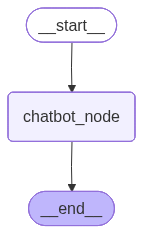

In [27]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
def chat(user_input: str, history):
    message = {"role": "user", "content": user_input}
    messages = [message]
    state = State(messages = messages)
    result = graph.invoke(state)
    print(result)
    return result["messages"][-1].content

gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='8095daaa-56b3-4d10-9109-705f66542d8c'), AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 214, 'prompt_tokens': 17, 'total_tokens': 231, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 200, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'google/gemma-4-e4b', 'system_fingerprint': 'google/gemma-4-e4b', 'id': 'chatcmpl-y8ue3ojeo0kiwmcz0vdb9d', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dcd0a-f1be-7062-8b52-0c88d6ab154a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 214, 'total_tokens': 231, 'input_token_details': {}, 'output_token_details': {'reasoning': 200}})]}
{'messages': [HumanMessage(content='make a joke', addi